In [ ]:
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import numpy as np

from datasets import BCDataDataset, PointsToGaussianHeatmap, collate_heatmap_points
from visualization import overlay_heatmap
from training import train
from models import NucleusLocalizationModel, heatmap_weighted_mse_loss
from utils.debug import print_info

import torch
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [2]:
with open("config.yaml", "r") as f:
    cfg = yaml.safe_load(f)


data_root = Path(cfg["paths"]["data_root"])
print(data_root)

/home/yeldos/Istanbul/obsidian_vault/work_AITU/IHC/DATASETS/BCData


In [3]:
heatmap_generator = PointsToGaussianHeatmap(out_hw=(160,160), in_hw=(640,640), sigma=2.0)

In [21]:
dataset = BCDataDataset(root = data_root,
                        split="train",
                        target_transform = heatmap_generator)

In [36]:
from tqdm import tqdm
count = 0
dists = []

def count_dists(pts, ds):
    n = len(pts)
    if n <= 1:
        return


    for i in range(n):
        min_dist = 100000
        found = False
        for j in range(n):
            if i==j: continue

            #print(f"1: {pts[i]}")
            #print(f"2: {pts[j]}")

            x1 = pts[i, 0]
            y1 = pts[i, 1]
            x2 = pts[j, 0]
            y2 = pts[j, 1]

            if (x1 == x2) or (y1 == y2):
                continue

            dist = torch.sqrt((x1 - x2)**2 + (y1 - y2)**2)
            if min_dist > dist:
                found = True
                min_dist = dist
            if dist < 1.:
                print(f"dist: {dist}, ij: {(i, j)}, pts1: {pts[i]}, pts2: {pts[j]}")
        if not found:
            print(pts[i])
            print(len(pts))
            raise ValueError("not found")
        ds.append(min_dist)


for i in tqdm(range(len(dataset))):
    imgs, heatmaps, pos_points, neg_points = dataset[i]
    #print_info(pos_points,'pos_points')

    count_dists(pos_points, dists)



  0%|          | 0/803 [00:00<?, ?it/s]

100%|██████████| 803/803 [01:32<00:00,  8.64it/s]


In [37]:
len(dists)


33049

In [38]:
max(dists)

tensor(560.0652)

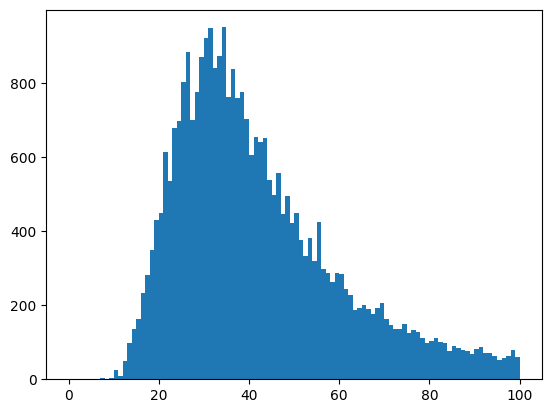

In [39]:
plt.hist(dists, bins=100, range=(0, 100))
plt.show()

In [45]:
np.sum([x < 10 for x in dists])

np.int64(12)